# Multi-State Markov Model per la Fragilità — Studio InveCe (Solo Metaboliti)

**Autore:** Filippo Saccomano  
**Tesi di laurea magistrale** — Politecnico di Milano

---

## Obiettivo

Questo notebook implementa un **Continuous-Time Multi-State Markov Model (CTMC-MSM)** multivariato con metaboliti plasmatici come covariate per modellare le transizioni tra stati di fragilità nella coorte InveCe.

**Scelte metodologiche chiave:**
- **Solo metaboliti** come covariate (nessuna variabile clinica)
- **Quintili calcolati pooled su tutti i timepoint** (sfruttano l'informazione longitudinale)
- **Modello multivariato** con pre-screening univariato + selezione
- La **storia** (stato precedente) è inclusa come covariata
- Le **auto-transizioni** (permanenza nello stesso stato) sono esplicitamente modellate e visualizzate
- 3 stati: Fit, Pre-fragile, Fragile
- 4 transizioni adiacenti permesse: 1↔2, 2↔3

## Metodologia: CTMC-MSM

La matrice delle intensità $Q$ (3×3):

$$Q_{ij} \geq 0 \quad (i \neq j), \qquad Q_{ii} = -\sum_{j \neq i} Q_{ij}$$

La matrice delle probabilità di transizione:

$$P(\Delta t) = e^{Q \cdot \Delta t}$$

Le **auto-transizioni** $P_{ii}(\Delta t)$ rappresentano la probabilità di rimanere nello stesso stato $i$ dopo $\Delta t$ anni.

L'effetto delle covariate:

$$q_{ij}(x) = q_{ij}^{(0)} \cdot e^{\beta_{ij}^T x}$$

dove $x$ include i quintili dei metaboliti e lo stato precedente (storia).

**Riferimenti:** Jackson (2011, JSS), Mendonça et al. (2020, Age & Ageing)

---
## 1. Setup & Costanti

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.linalg import expm
from scipy.optimize import minimize
from scipy.stats import chi2, norm as _norm
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────
MASTER_PATH = os.path.join('data', 'df_master.csv')

# ── Costanti temporali ─────────────────────────────────────────────────
TIMES         = [1, 2, 3, 4]
TIME_TO_YEARS = {1: 0, 2: 2, 3: 4, 4: 8}
BASELINE_YEAR = 2010

# ── Cutoff Frailty Index → 3 stati ────────────────────────────────────
FIT_THR   = 0.10
FRAIL_THR = 0.25
FLOOR_THR = 40

# ── Etichette ─────────────────────────────────────────────────────────
STATE_NAMES  = {1: 'Fit', 2: 'Pre-fragile', 3: 'Fragile'}
STATE_COLORS = {1: '#27ae60', 2: '#f39c12', 3: '#e74c3c'}
N_STATES     = 3

# ── Transizioni permesse (0-indexed) ──────────────────────────────────
TRANS        = [(0,1), (1,0), (1,2), (2,1)]
TRANS_LABELS = ['1→2', '2→1', '2→3', '3→2']
N_TRANS      = len(TRANS)

print('Setup completato.')
print(f'Transizioni permesse ({N_TRANS}): {TRANS_LABELS}')

Setup completato.
Transizioni permesse (4): ['1→2', '2→1', '2→3', '3→2']


---
## 2. Caricamento Dati

In [2]:
df = pd.read_csv(MASTER_PATH, low_memory=False)
print(f'Shape df_master: {df.shape}')
print(f'Soggetti unici:  {df["Code"].nunique()}')
print(f'Timepoint unici: {sorted(df["Time"].unique())}')

# ── Identifica colonne metaboliti ─────────────────────────────────────
NON_MET_COLS = ['Code', 'Time', 'FI', 'annonascita', 'HMDB_Metabolite',
                'Sesso', 'BMI1', 'C_renale', 'C_epatic10', 'AnniScuo',
                'Subject', 'Years', 'Age']
met_cols_all = [c for c in df.columns if c not in NON_MET_COLS]
print(f'Metaboliti totali: {len(met_cols_all)}')

# ── Forza numerico ────────────────────────────────────────────────────
for _c in ['FI', 'annonascita']:
    if _c in df.columns:
        df[_c] = pd.to_numeric(df[_c], errors='coerce')
df[met_cols_all] = df[met_cols_all].apply(pd.to_numeric, errors='coerce')

# ── Calcola Years e Age ───────────────────────────────────────────────
df['Years'] = df['Time'].map(TIME_TO_YEARS)
if 'Age' not in df.columns or df['Age'].isna().all():
    df['Age'] = BASELINE_YEAR + df['Years'] - df['annonascita']

df.head(3)

Shape df_master: (2436, 206)
Soggetti unici:  609
Timepoint unici: [1, 2, 3, 4]
Metaboliti totali: 193


,Code,Time,FI,annonascita,HMDB_Metabolite,Sesso,BMI1,C_renale,C_epatic10,AnniScuo,...,157136,168129,190097,192859,206004,247273,96893,125401,Years,Age
0,9,1,0.060606,1935,int_9,2.0,23.12467,1,1,12.0,...,6.88,0.2,0.04,0.06,0.02,15506805.00,0.88,0.08,0,75
1,9,2,0.060606,1935,int_2_9,NaN,23.733214,1,1,NaN,...,3675.60,0.2,0.04,0.06,0.02,1.56,3210.50,751.70,2,77
2,9,3,0.060606,1935,int_4_9,NaN,23.936062,1,1,NaN,...,6.88,0.2,0.04,0.06,3903.70,1.56,5200.70,0.08,4,79


---
## 3. Definizione degli Stati di Fragilità

| Stato | Etichetta | Cutoff FI |
|-------|-----------|----------|
| 1     | Fit       | FI < 0.10 |
| 2     | Pre-fragile | 0.10 ≤ FI < 0.25 |
| 3     | Fragile   | FI ≥ 0.25 |

In [3]:
def fi_to_state(fi):
    """Converte FI in stato 1/2/3."""
    if pd.isna(fi):
        return np.nan
    if fi < FIT_THR:
        return 1
    elif fi < FRAIL_THR:
        return 2
    else:
        return 3

df['state'] = df['FI'].apply(fi_to_state)
df['state_label'] = df['state'].map(STATE_NAMES)

# ── Distribuzione stati per timepoint ────────────────────────────────
state_dist = (df.groupby(['Time', 'state_label'])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=['Fit', 'Pre-fragile', 'Fragile'], fill_value=0))
print('Distribuzione stati per timepoint:')
display(state_dist)

# ── Filtra soggetti completi ──────────────────────────────────────────
def has_all_states(g):
    return (g['Time'].nunique() == 4) and (g['state'].notna().all())

complete_codes = df.groupby('Code').filter(has_all_states)['Code'].unique()
df_msm = df[df['Code'].isin(complete_codes)].copy().sort_values(['Code','Time']).reset_index(drop=True)
print(f'\nSoggetti completi per MSM: {df_msm["Code"].nunique()}')
print(f'Osservazioni totali: {len(df_msm)}')

Distribuzione stati per timepoint:


state_label,Fit,Pre-fragile,Fragile
Time,,,
1,299,310,0
2,247,338,24
3,209,365,35
4,115,347,147



Soggetti completi per MSM: 609
Osservazioni totali: 2436


---
## 4. Analisi Esplorativa delle Transizioni

Include esplicitamente le **auto-transizioni** (permanenza nello stesso stato).

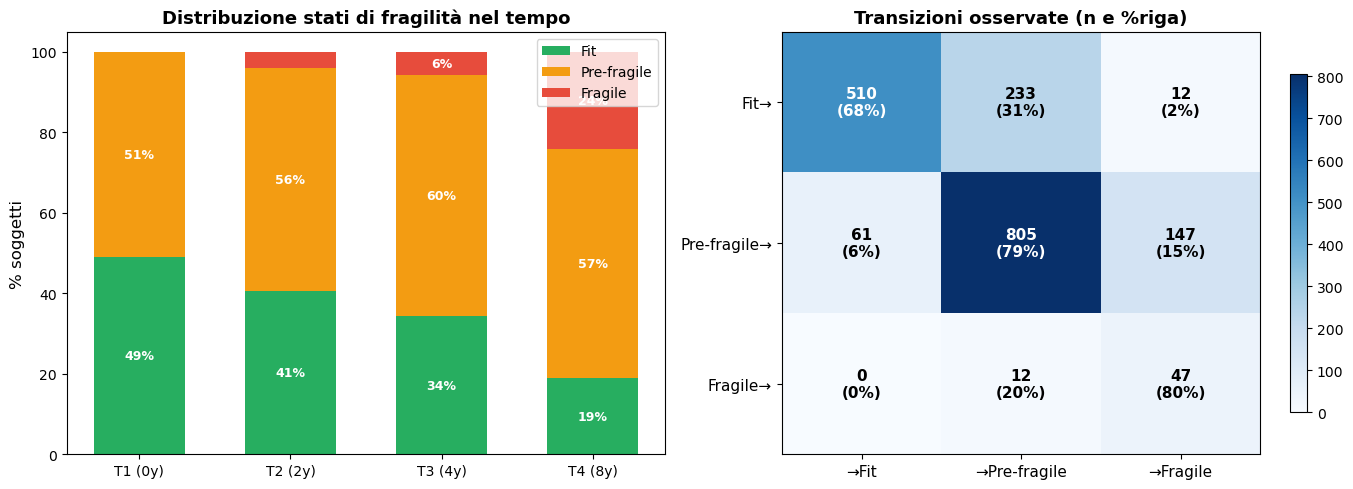


Coppie totali: 1827
Auto-transizioni (rimangono nello stesso stato): 1362 (74.5%)
Cambi di stato: 465 (25.5%)
  Fit: 510/755 rimangono (68%)
  Pre-fragile: 805/1013 rimangono (79%)
  Fragile: 47/59 rimangono (80%)


In [4]:
# ── Distribuzione stati per timepoint (%) ────────────────────────────
state_pct = (df_msm.groupby(['Time', 'state'])
              .size()
              .unstack(fill_value=0))
state_pct = state_pct.div(state_pct.sum(axis=1), axis=0) * 100
state_pct.index = [f'T{t} ({TIME_TO_YEARS[t]}y)' for t in state_pct.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart distribuzione stati ─────────────────────────────────────
ax = axes[0]
bottom = np.zeros(len(state_pct))
for s in [1, 2, 3]:
    if s in state_pct.columns:
        ax.bar(state_pct.index, state_pct[s], bottom=bottom,
               color=STATE_COLORS[s], label=STATE_NAMES[s], width=0.6)
        bottom += state_pct[s].values
ax.set_ylabel('% soggetti', fontsize=12)
ax.set_title('Distribuzione stati di fragilità nel tempo', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 105)
for i, (idx, row) in enumerate(state_pct.iterrows()):
    cum = 0
    for s in [1, 2, 3]:
        if s in row.index:
            v = row[s]
            if v > 5:
                ax.text(i, cum + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
            cum += v

# ── Matrice di transizione osservata (con auto-transizioni) ───────────
trans_matrix = np.zeros((3, 3), dtype=int)
for code, grp in df_msm.groupby('Code'):
    grp = grp.sort_values('Time')
    states = grp['state'].values
    for k in range(len(states) - 1):
        s0, s1 = int(states[k]), int(states[k+1])
        trans_matrix[s0-1, s1-1] += 1

ax2 = axes[1]
im = ax2.imshow(trans_matrix, cmap='Blues', aspect='auto')
for i in range(3):
    for j in range(3):
        pct_val = trans_matrix[i, j] / max(1, trans_matrix[i, :].sum()) * 100
        label = f'{trans_matrix[i, j]}\n({pct_val:.0f}%)'
        ax2.text(j, i, label,
                ha='center', va='center', fontsize=11,
                color='white' if trans_matrix[i,j] > trans_matrix.max()*0.5 else 'black',
                fontweight='bold')
ax2.set_xticks(range(3))
ax2.set_yticks(range(3))
ax2.set_xticklabels([f'→{STATE_NAMES[s]}' for s in [1,2,3]], fontsize=11)
ax2.set_yticklabels([f'{STATE_NAMES[s]}→' for s in [1,2,3]], fontsize=11)
ax2.set_title('Transizioni osservate (n e %riga)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

# ── Statistiche auto-transizioni ──────────────────────────────────────
total_pairs = trans_matrix.sum()
auto_trans = sum(trans_matrix[i,i] for i in range(3))
print(f'\nCoppie totali: {total_pairs}')
print(f'Auto-transizioni (rimangono nello stesso stato): {auto_trans} ({100*auto_trans/total_pairs:.1f}%)')
print(f'Cambi di stato: {total_pairs - auto_trans} ({100*(total_pairs-auto_trans)/total_pairs:.1f}%)')
for i in range(3):
    row_total = trans_matrix[i, :].sum()
    if row_total > 0:
        auto_s = trans_matrix[i,i]
        print(f'  {STATE_NAMES[i+1]}: {auto_s}/{row_total} rimangono ({100*auto_s/row_total:.0f}%)')

---
## 5. Floor Effect & Selezione Metaboliti

Metaboliti con `% floor ≤ 40%` vengono mantenuti.

Metaboliti totali: 193
Metaboliti con floor ≤ 40%: 39
Metaboliti esclusi: 154


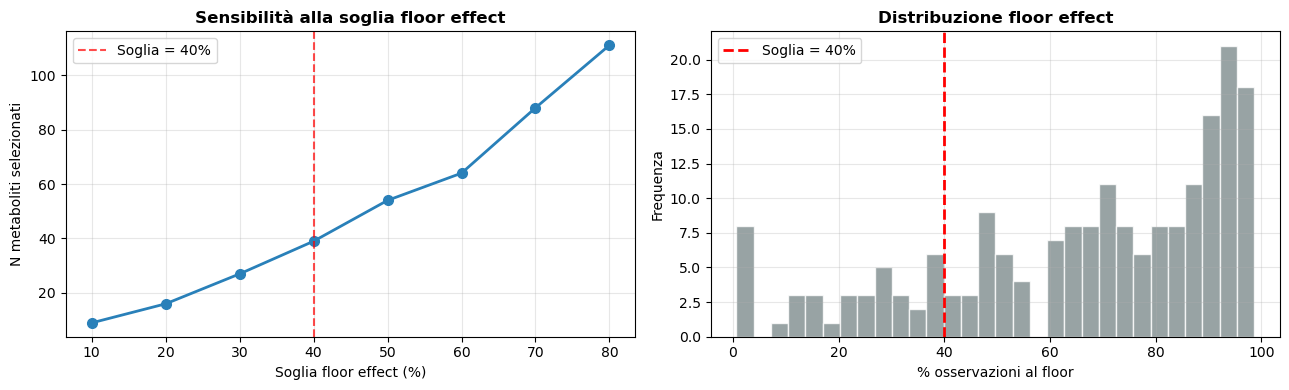

In [5]:
met_data = df_msm[met_cols_all].copy()
floor_vals = met_data.min(axis=0)
is_floor   = met_data.eq(floor_vals, axis=1)
pct_floor  = (is_floor.mean(axis=0) * 100).sort_values(ascending=False)

mets_sel = pct_floor[pct_floor <= FLOOR_THR].index.tolist()
print(f'Metaboliti totali: {len(met_cols_all)}')
print(f'Metaboliti con floor ≤ {FLOOR_THR}%: {len(mets_sel)}')
print(f'Metaboliti esclusi: {len(met_cols_all) - len(mets_sel)}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
thresholds = [10, 20, 30, 40, 50, 60, 70, 80]
surviving  = [(pct_floor <= t).sum() for t in thresholds]
ax.plot(thresholds, surviving, 'o-', color='#2980b9', linewidth=2, markersize=7)
ax.axvline(FLOOR_THR, color='red', linestyle='--', alpha=0.7, label=f'Soglia = {FLOOR_THR}%')
ax.set_xlabel('Soglia floor effect (%)')
ax.set_ylabel('N metaboliti selezionati')
ax.set_title('Sensibilità alla soglia floor effect', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.hist(pct_floor.values, bins=30, color='#7f8c8d', edgecolor='white', alpha=0.8)
ax2.axvline(FLOOR_THR, color='red', linestyle='--', linewidth=2, label=f'Soglia = {FLOOR_THR}%')
ax2.set_xlabel('% osservazioni al floor')
ax2.set_ylabel('Frequenza')
ax2.set_title('Distribuzione floor effect', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Discretizzazione in Quintili (Pooled Temporale)

A differenza dell'approccio standard che usa solo il baseline, qui i quintili sono calcolati **poolando le misurazioni di tutti i timepoint**.

Questo approccio:
- Sfrutta l'informazione longitudinale completa
- Produce cutoff più robusti e stabili
- Permette che lo stesso soggetto possa cambiare quintile nel tempo (covariate time-varying)

In [6]:
# ── Calcolo quintili POOLED su tutti i timepoint ─────────────────────
quint_breakpoints = {}
for met in mets_sel:
    vals = df_msm[met].dropna()
    if len(vals) < 20:
        continue
    try:
        _, bins = pd.qcut(vals, 5, retbins=True, duplicates='drop')
        if len(bins) >= 3:  # almeno 2 gruppi
            quint_breakpoints[met] = bins
    except Exception:
        continue

# ── Assegna quintili a ogni osservazione usando breakpoints pooled ────
mets_quint_valid = list(quint_breakpoints.keys())
for met in mets_quint_valid:
    bins = quint_breakpoints[met]
    df_msm[f'Q_{met}'] = pd.cut(df_msm[met], bins=bins, labels=False, include_lowest=True)
    df_msm[f'Q_{met}'] = df_msm[f'Q_{met}'] + 1  # 1-indexed

quint_cols = [f'Q_{met}' for met in mets_quint_valid]
print(f'Metaboliti con quintili validi (pooled): {len(mets_quint_valid)}')

# ── Verifica che i quintili siano time-varying ────────────────────────
if quint_cols:
    ex_col = quint_cols[0]
    n_changing = 0
    for code, grp in df_msm.groupby('Code'):
        if grp[ex_col].nunique() > 1:
            n_changing += 1
    tot = df_msm['Code'].nunique()
    print(f'Esempio ({mets_quint_valid[0][:30]}...): {n_changing}/{tot} soggetti cambiano quintile nel tempo')
    print(f'\nDistribuzione quintili (primo metabolita, pooled):')
    print(df_msm[ex_col].value_counts().sort_index())

Metaboliti con quintili validi (pooled): 39
Esempio (Resveratrol-O-glucuronide...): 594/609 soggetti cambiano quintile nel tempo

Distribuzione quintili (primo metabolita, pooled):
Q_Resveratrol-O-glucuronide
1    975
2    487
3    487
4    487
Name: count, dtype: int64


---
## 7. Preparazione Dati per MSM (con Storia)

Per ogni coppia di transizioni consecutive includiamo:
- **Quintili time-varying** dei metaboliti (valore al timepoint di partenza)
- **Stato precedente** (storia): lo stato alla wave precedente a quella di partenza

Per la prima transizione (T1→T2) lo stato precedente non è disponibile, usiamo lo stato corrente.

In [7]:
# ── Costruisci dataset transizioni con storia ─────────────────────────
rows = []
for code, grp in df_msm.groupby('Code'):
    grp = grp.sort_values('Time')
    rlist = grp.to_dict('records')
    for k in range(len(rlist) - 1):
        r0, r1 = rlist[k], rlist[k+1]
        dt = TIME_TO_YEARS[r1['Time']] - TIME_TO_YEARS[r0['Time']]
        s0 = int(r0['state'])
        s1 = int(r1['state'])
        
        # Stato precedente (storia)
        if k > 0:
            prev_state = int(rlist[k-1]['state'])
        else:
            prev_state = s0  # Per la prima transizione, prev = current
        
        row = {
            'Code': code,
            't_from': r0['Time'],
            't_to': r1['Time'],
            'dt': dt,
            'state_from': s0,
            'state_to': s1,
            'prev_state': prev_state,
            # Indicatori storia
            'was_improving': int(prev_state > s0) if k > 0 else 0,
            'was_worsening': int(prev_state < s0) if k > 0 else 0,
        }
        # Quintili metaboliti (time-varying: valore al timepoint di partenza)
        for qc in quint_cols:
            row[qc] = r0.get(qc, np.nan)
        rows.append(row)

df_pairs = pd.DataFrame(rows)
print(f'Dataset transizioni: {len(df_pairs)} righe')
print(f'Distribuzione Δt: {df_pairs["dt"].value_counts().to_dict()}')

# ── Statistiche storia ────────────────────────────────────────────────
print(f'\nStoria (distribuzione stato precedente):')
print(df_pairs['prev_state'].value_counts().sort_index())
print(f'\nSoggetti con miglioramento precedente: {df_pairs["was_improving"].sum()}')
print(f'Soggetti con peggioramento precedente: {df_pairs["was_worsening"].sum()}')

# ── Distribuzione auto-transizioni nel dataset ────────────────────────
auto_mask = df_pairs['state_from'] == df_pairs['state_to']
print(f'\nAuto-transizioni nel dataset: {auto_mask.sum()} ({100*auto_mask.mean():.1f}%)')
for s in [1, 2, 3]:
    mask_s = df_pairs['state_from'] == s
    if mask_s.sum() > 0:
        auto_s = (df_pairs.loc[mask_s, 'state_to'] == s).sum()
        print(f'  {STATE_NAMES[s]}: {auto_s}/{mask_s.sum()} rimangono ({100*auto_s/mask_s.sum():.0f}%)')

df_pairs.head(6)

Dataset transizioni: 1827 righe
Distribuzione Δt: {2: 1218, 4: 609}

Storia (distribuzione stato precedente):
prev_state
1    845
2    958
3     24
Name: count, dtype: int64

Soggetti con miglioramento precedente: 45
Soggetti con peggioramento precedente: 170

Auto-transizioni nel dataset: 1362 (74.5%)
  Fit: 510/755 rimangono (68%)
  Pre-fragile: 805/1013 rimangono (79%)
  Fragile: 47/59 rimangono (80%)


,Code,t_from,t_to,dt,state_from,state_to,prev_state,was_improving,was_worsening,Q_Resveratrol-O-glucuronide,...,Q_3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;,Q_5-acetylamino-6-amino-3-methyluracil ((AAMU),Q_107237,Q_2-Hydroxycinnamic acid,Q_133960,Q_121399,Q_Hippuric acid,Q_Isorhamnetin,Q_myo-Inositol,Q_Uric acid
0,9,1,2,2,1,1,1,0,0,2,...,3,1,1,4,5,1,1,1,1,3
1,9,2,3,2,1,1,1,0,0,2,...,3,1,1,5,1,2,2,2,2,1
2,9,3,4,4,1,1,1,0,0,1,...,2,3,2,4,3,3,3,1,1,1
3,11,1,2,2,2,2,2,0,0,2,...,4,5,5,4,3,5,5,5,4,3
4,11,2,3,2,2,2,2,0,0,1,...,4,2,1,5,1,1,4,4,3,2
5,11,3,4,4,2,2,2,0,0,1,...,1,2,2,1,1,2,5,3,3,1


---
## 8. Implementazione CTMC-MSM

Le intensità di transizione sono parametrizzate come:

$$q_{ij}(x) = q_{ij}^{(0)} \cdot \exp(\beta_{ij}^T x)$$

La log-verosimiglianza include esplicitamente le auto-transizioni attraverso la diagonale di $P(\Delta t)$:

$$\ell = \sum_n \log P_{s_{n,k} \to s_{n,k+1}}(\Delta t_{nk} \mid x_n)$$

dove $P_{ii}(\Delta t)$ contribuisce quando il soggetto rimane nello stato $i$.

In [8]:
# ════════════════════════════════════════════════════════════════════════
#  CTMC-MSM: funzioni core
# ════════════════════════════════════════════════════════════════════════

def make_Q(log_q):
    """Costruisce la matrice Q 3×3 da N_TRANS log-intensità."""
    Q = np.zeros((3, 3))
    for k, (i, j) in enumerate(TRANS):
        Q[i, j] = np.exp(np.clip(log_q[k], -15, 10))
    for i in range(3):
        Q[i, i] = -Q[i, :].sum()
    return Q

def trans_prob(Q, dt):
    """Matrice probabilità P(dt) = expm(Q*dt). Auto-transizioni sulla diagonale."""
    return expm(Q * dt)

def batch_expm_ctmc(Q_batch_dt):
    """Matrix exponential batch via eigendecomposition."""
    evals, evecs = np.linalg.eig(Q_batch_dt)
    exp_evals = np.exp(np.real(evals))
    diag_exp  = exp_evals[:, :, np.newaxis] * np.eye(3)[np.newaxis]
    evecs_inv = np.linalg.inv(evecs)
    P = np.real(evecs @ diag_exp @ evecs_inv)
    P = np.clip(P, 0.0, 1.0)
    return P

# ── Modello nullo ─────────────────────────────────────────────────────
def neg_ll_null(log_q, dt_arr, sf_arr, st_arr):
    """Neg-logL senza covariate. Include auto-transizioni (diagonale di P)."""
    ll = 0.0
    for dt in np.unique(dt_arr):
        mask = dt_arr == dt
        P = trans_prob(make_Q(log_q), dt)
        p = np.maximum(P[sf_arr[mask], st_arr[mask]], 1e-300)
        ll += np.sum(np.log(p))
    return -ll

# ── Modello con covariate (batch) ─────────────────────────────────────
def neg_ll_cov_batch(params, dt_arr, sf_arr, st_arr, X):
    """Neg-logL vettorizzato con eigendecomposition batch."""
    n_cov      = X.shape[1]
    log_q_base = params[:N_TRANS]
    betas      = params[N_TRANS:].reshape(N_TRANS, n_cov)

    log_q_all = log_q_base[np.newaxis, :] + (betas @ X.T).T
    log_q_all = np.clip(log_q_all, -15, 10)

    n = len(dt_arr)
    Q_batch = np.zeros((n, 3, 3))
    for k, (i, j) in enumerate(TRANS):
        Q_batch[:, i, j] = np.exp(log_q_all[:, k])
    for i_s in range(3):
        Q_batch[:, i_s, i_s] = -Q_batch[:, i_s, :].sum(axis=1)

    ll = 0.0
    for dt in np.unique(dt_arr):
        mask  = (dt_arr == dt)
        n_sub = mask.sum()
        P_sub = batch_expm_ctmc(Q_batch[mask] * dt)
        p     = np.maximum(P_sub[np.arange(n_sub), sf_arr[mask], st_arr[mask]], 1e-300)
        ll   += np.sum(np.log(p))
    return -ll

# ── Modello quintile univariato (con cache) ───────────────────────────
def neg_ll_quintile(params, dt_arr, sf_arr, st_arr, q_arr):
    """Neg-logL per quintile singolo metabolita."""
    log_q_base = params[:N_TRANS]
    betas_met  = params[N_TRANS:]

    P_cache = {}
    for dt in np.unique(dt_arr):
        for qv in np.unique(q_arr[~np.isnan(q_arr)]):
            log_q = log_q_base + betas_met * qv
            P_cache[(dt, qv)] = trans_prob(make_Q(log_q), dt)

    ll = 0.0
    q_mean = np.nanmean(q_arr)
    for k in range(len(dt_arr)):
        qv  = q_arr[k] if not np.isnan(q_arr[k]) else q_mean
        key = (dt_arr[k], qv)
        if key not in P_cache:
            log_q = log_q_base + betas_met * qv
            P_cache[key] = trans_prob(make_Q(log_q), dt_arr[k])
        p = max(P_cache[key][sf_arr[k], st_arr[k]], 1e-300)
        ll += np.log(p)
    return -ll

# ── Ottimizzatore ─────────────────────────────────────────────────────
def fit_msm(neg_ll_fn, x0, args, bounds=None, method='L-BFGS-B', maxiter=3000):
    if bounds is None:
        bounds = [(-12, 6)] * N_TRANS + [(-8, 8)] * (len(x0) - N_TRANS)
    return minimize(
        neg_ll_fn, x0, args=args, method=method,
        bounds=bounds,
        options={'maxiter': maxiter, 'ftol': 1e-10, 'gtol': 1e-6}
    )

# ── Standard error via Hessiano numerico ──────────────────────────────
def compute_se_hessian(neg_ll_fn, params_hat, args, eps=1e-4):
    n  = len(params_hat)
    H  = np.zeros((n, n))
    f0 = neg_ll_fn(params_hat, *args)

    f_plus  = np.zeros(n)
    f_minus = np.zeros(n)
    for i in range(n):
        ei = np.zeros(n); ei[i] = eps
        f_plus[i]  = neg_ll_fn(params_hat + ei, *args)
        f_minus[i] = neg_ll_fn(params_hat - ei, *args)

    for i in range(n):
        H[i, i] = (f_plus[i] - 2*f0 + f_minus[i]) / eps**2
    for i in range(n):
        for j in range(i+1, n):
            ei = np.zeros(n); ei[i] = eps
            ej = np.zeros(n); ej[j] = eps
            fij = neg_ll_fn(params_hat + ei + ej, *args)
            H[i, j] = (fij - f_plus[i] - f_plus[j] + f0) / eps**2
            H[j, i] = H[i, j]

    try:
        V  = np.linalg.inv(H)
        se = np.sqrt(np.abs(np.diag(V)))
    except np.linalg.LinAlgError:
        se = np.full(n, np.nan)
    return se

print('Funzioni CTMC-MSM definite.')
print(f'Parametri modello nullo: {N_TRANS}')
print('Auto-transizioni modellate esplicitamente tramite P_ii(Δt)')

Funzioni CTMC-MSM definite.
Parametri modello nullo: 4
Auto-transizioni modellate esplicitamente tramite P_ii(Δt)


---
## 9. Modello Nullo

Il modello nullo stima le intensità baseline. Il **sojourn time** $\bar{t}_i = 1/|Q_{ii}|$ rappresenta il tempo medio in ciascuno stato, catturando le auto-transizioni.

In [9]:
# ── Prepara array numpy ───────────────────────────────────────────────
dt_arr = df_pairs['dt'].values.astype(float)
sf_arr = (df_pairs['state_from'] - 1).values.astype(int)
st_arr = (df_pairs['state_to']   - 1).values.astype(int)

# ── Fit ────────────────────────────────────────────────────────────────
log_q_init = np.full(N_TRANS, np.log(0.15))
print('Fitting modello nullo...')
res_null = fit_msm(neg_ll_null, log_q_init, args=(dt_arr, sf_arr, st_arr))
print(f'  Converged: {res_null.success}  |  -logL = {res_null.fun:.2f}')

se_null = compute_se_hessian(neg_ll_null, res_null.x, (dt_arr, sf_arr, st_arr))
q_hat = np.exp(res_null.x)
Q_null = make_Q(res_null.x)

# ── Tabella intensità ─────────────────────────────────────────────────
df_intensities = pd.DataFrame({
    'Transizione': TRANS_LABELS,
    'Intensità (q)': q_hat.round(4),
    'SE (log)': se_null.round(4),
    'IC95% inf': np.exp(res_null.x - 1.96*se_null).round(4),
    'IC95% sup': np.exp(res_null.x + 1.96*se_null).round(4),
})
print('\nIntensità di transizione (per anno):')
display(df_intensities)

# ── Q matrix ──────────────────────────────────────────────────────────
print('\nMatrice Q:')
display(pd.DataFrame(Q_null.round(4),
                     index=list(STATE_NAMES.values()),
                     columns=list(STATE_NAMES.values())))

# ── Sojourn time ──────────────────────────────────────────────────────
sojourn = pd.DataFrame({
    'Stato': list(STATE_NAMES.values()),
    'Sojourn time medio (anni)': [1/abs(Q_null[i,i]) for i in range(3)]
})
print('\nSojourn time medio (tempo atteso nello stesso stato):')
display(sojourn.round(2))

Fitting modello nullo...
  Converged: True  |  -logL = 1139.17

Intensità di transizione (per anno):


,Transizione,Intensità (q),SE (log),IC95% inf,IC95% sup
0,1→2,0.1669,0.0659,0.1467,0.1900
1,2→1,0.0316,0.1311,0.0245,0.0409
2,2→3,0.0628,0.0848,0.0532,0.0742
3,3→2,0.0611,0.2932,0.0344,0.1086



Matrice Q:


,Fit,Pre-fragile,Fragile
Fit,-0.1669,0.1669,0.0000
Pre-fragile,0.0316,-0.0945,0.0628
Fragile,0.0000,0.0611,-0.0611



Sojourn time medio (tempo atteso nello stesso stato):


,Stato,Sojourn time medio (anni)
0,Fit,5.99
1,Pre-fragile,10.59
2,Fragile,16.37


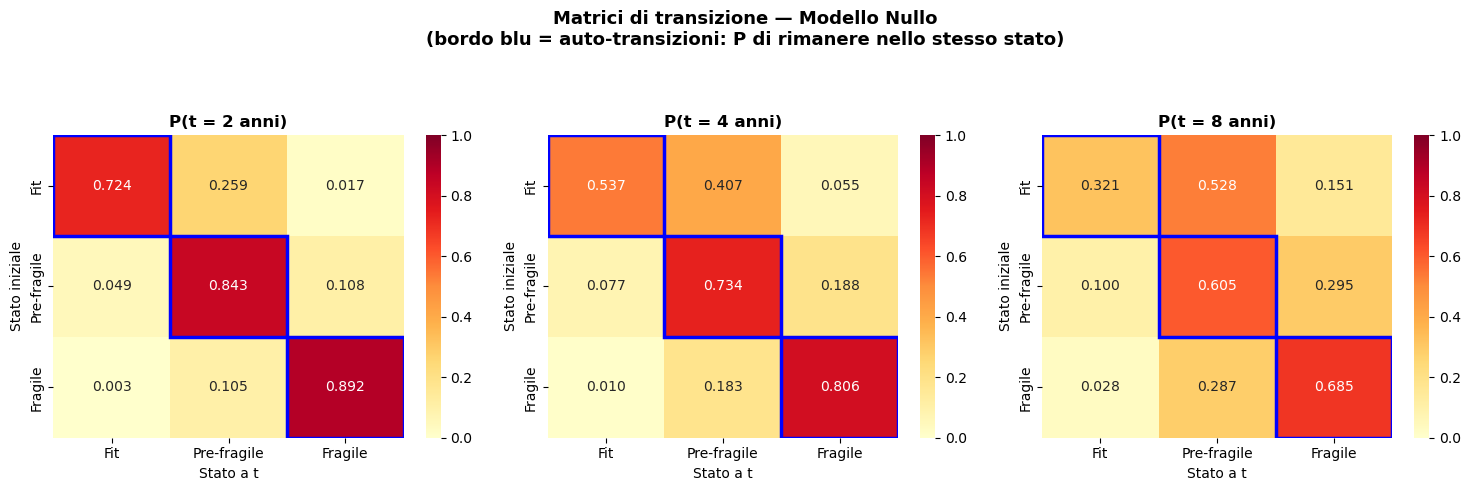


P(t=2 anni) — diagonale = prob. di rimanere nello stato:
               Fit  Pre-fragile  Fragile
Fit          0.724        0.259    0.017
Pre-fragile  0.049        0.843    0.108
Fragile      0.003        0.105    0.892

P(t=4 anni) — diagonale = prob. di rimanere nello stato:
               Fit  Pre-fragile  Fragile
Fit          0.537        0.407    0.055
Pre-fragile  0.077        0.734    0.188
Fragile      0.010        0.183    0.806

P(t=8 anni) — diagonale = prob. di rimanere nello stato:
               Fit  Pre-fragile  Fragile
Fit          0.321        0.528    0.151
Pre-fragile  0.100        0.605    0.295
Fragile      0.028        0.287    0.685


In [10]:
# ── Probabilità di transizione a vari orizzonti (con auto-transizioni evidenziate) ──
horizons = [2, 4, 8]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, t in zip(axes, horizons):
    P = trans_prob(Q_null, t)
    sns.heatmap(P, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
                xticklabels=[STATE_NAMES[s] for s in [1,2,3]],
                yticklabels=[STATE_NAMES[s] for s in [1,2,3]],
                vmin=0, vmax=1, cbar=True)
    # Evidenzia diagonale (auto-transizioni) con bordo blu
    for i in range(3):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                     edgecolor='blue', linewidth=2.5))
    ax.set_title(f'P(t = {t} anni)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Stato a t')
    ax.set_ylabel('Stato iniziale')

plt.suptitle('Matrici di transizione — Modello Nullo\n(bordo blu = auto-transizioni: P di rimanere nello stesso stato)',
             fontsize=13, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

# Stampa tabelle
for t in horizons:
    P = trans_prob(Q_null, t)
    print(f'\nP(t={t} anni) — diagonale = prob. di rimanere nello stato:')
    print(pd.DataFrame(P.round(3), index=list(STATE_NAMES.values()),
                       columns=list(STATE_NAMES.values())).to_string())

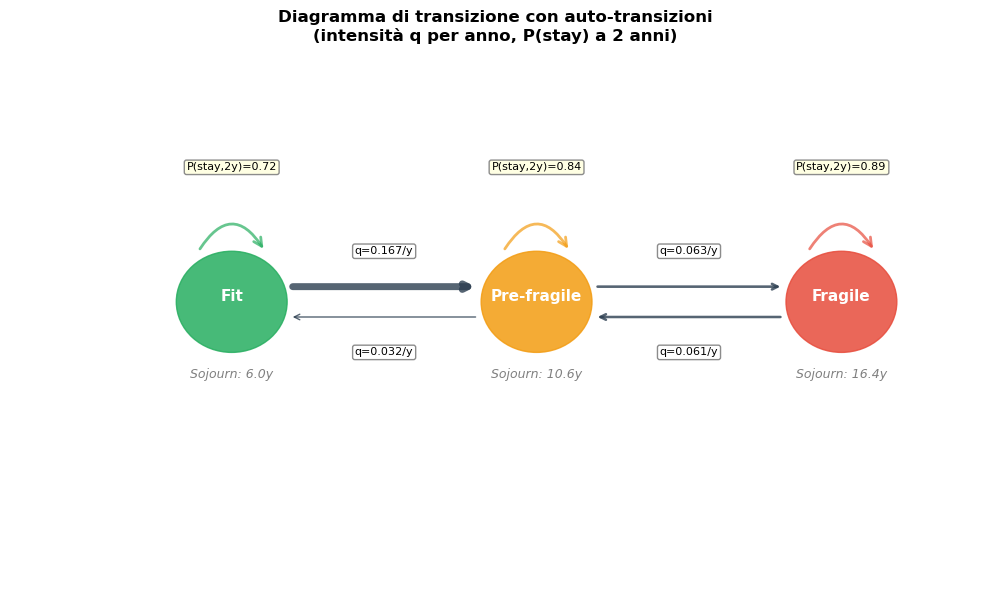

In [11]:
# ── Diagramma di transizione con AUTO-TRANSIZIONI esplicite ──────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(-0.5, 3.0)
ax.set_ylim(-0.3, 1.8)
ax.axis('off')

pos = {0: (0.3, 0.8), 1: (1.4, 0.8), 2: (2.5, 0.8)}
P_2y = trans_prob(Q_null, 2)

# ── Disegna nodi con auto-transizione ─────────────────────────────────
for i, (xi, yi) in pos.items():
    circle = plt.Circle((xi, yi), 0.20, color=STATE_COLORS[i+1], alpha=0.85, zorder=5)
    ax.add_patch(circle)
    ax.text(xi, yi + 0.02, STATE_NAMES[i+1], ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=6)
    
    # Sojourn time sotto
    sojourn_t = 1 / abs(Q_null[i, i])
    ax.text(xi, yi - 0.30, f'Sojourn: {sojourn_t:.1f}y', ha='center',
            fontsize=9, color='gray', style='italic')
    
    # Auto-transizione (arco circolare sopra il nodo)
    p_stay = P_2y[i, i]
    arc = mpatches.FancyArrowPatch(
        (xi - 0.12, yi + 0.20), (xi + 0.12, yi + 0.20),
        connectionstyle="arc3,rad=-0.8",
        arrowstyle='->', mutation_scale=15,
        color=STATE_COLORS[i+1], linewidth=2, alpha=0.7, zorder=4)
    ax.add_patch(arc)
    ax.text(xi, yi + 0.52, f'P(stay,2y)={p_stay:.2f}',
            ha='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                     edgecolor='gray', alpha=0.9))

# ── Disegna frecce tra stati ──────────────────────────────────────────
q_max = max(q_hat)
for k, (i, j) in enumerate(TRANS):
    xi, yi = pos[i]
    xj, yj = pos[j]
    q_ij = q_hat[k]
    lw = max(1, 5 * q_ij / q_max)
    offset = 0.06 if j > i else -0.06
    ax.annotate('', xy=(xj - np.sign(j-i)*0.21, yj + offset),
                xytext=(xi + np.sign(j-i)*0.21, yi + offset),
                arrowprops=dict(arrowstyle='->', lw=lw, color='#2c3e50', alpha=0.8))
    mx = (xi + xj) / 2
    my = yi + offset + (0.14 if offset > 0 else -0.14)
    ax.text(mx, my, f'q={q_ij:.3f}/y', ha='center', va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                     edgecolor='gray', alpha=0.9))

ax.set_title('Diagramma di transizione con auto-transizioni\n(intensità q per anno, P(stay) a 2 anni)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Pre-screening Univariato dei Metaboliti

Per gestire l'alta dimensionalità, applichiamo un **pre-screening univariato**:
1. Fit di un modello MSM per ciascun metabolita (quintile come covariata)
2. Selezione dei metaboliti con p-value < 0.10 (non corretto) su almeno una transizione
3. I metaboliti selezionati entrano nel modello multivariato finale

In [12]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs): return iterable

records_univ = []
failed_mets = []

print(f'Pre-screening univariato su {len(quint_cols)} metaboliti...\n')

for qc in tqdm(quint_cols):
    met_name = qc[2:]
    q_arr = pd.to_numeric(df_pairs[qc], errors='coerce').values.astype(float)
    n_valid = (~np.isnan(q_arr)).sum()
    if n_valid < 50:
        failed_mets.append(met_name)
        continue

    init = np.concatenate([res_null.x, np.zeros(N_TRANS)])
    try:
        res_met = fit_msm(neg_ll_quintile, init,
                          args=(dt_arr, sf_arr, st_arr, q_arr))
        se_met = compute_se_hessian(neg_ll_quintile, res_met.x,
                                    args=(dt_arr, sf_arr, st_arr, q_arr))
        betas_met = res_met.x[N_TRANS:]
        se_bm     = se_met[N_TRANS:]

        lrt_s = 2 * max(0.0, res_null.fun - res_met.fun)
        lrt_p = 1 - chi2.cdf(lrt_s, df=N_TRANS)

        for k, (i, j) in enumerate(TRANS):
            beta = betas_met[k]
            se_b = se_bm[k]
            hr   = np.exp(beta)
            pv   = 2 * _norm.sf(abs(beta/se_b)) if (se_b > 0 and not np.isnan(se_b)) else np.nan
            records_univ.append({
                'Metabolita': met_name, 'Transizione': TRANS_LABELS[k],
                'Beta': float(beta), 'SE': float(se_b),
                'HR': float(hr),
                'HR_lo': float(np.exp(beta - 1.96*se_b)),
                'HR_hi': float(np.exp(beta + 1.96*se_b)),
                'p_value': float(pv) if not np.isnan(pv) else np.nan,
                'LRT_p': float(lrt_p),
            })
    except Exception:
        failed_mets.append(met_name)

df_hr_univ = pd.DataFrame(records_univ)

# ── FDR correction ────────────────────────────────────────────────────
df_hr_fdr = []
for trans in df_hr_univ['Transizione'].unique():
    sub = df_hr_univ[df_hr_univ['Transizione'] == trans].copy()
    pvals = sub['p_value'].fillna(1.0).values
    _, q_vals, _, _ = multipletests(pvals, method='fdr_bh')
    sub['q_value'] = q_vals
    df_hr_fdr.append(sub)
df_hr_univ = pd.concat(df_hr_fdr, ignore_index=True)

# ── Selezione metaboliti per modello multivariato ─────────────────────
P_THRESH_SCREEN = 0.10
selected_mets = df_hr_univ[df_hr_univ['p_value'] < P_THRESH_SCREEN]['Metabolita'].unique()

print(f'\nMetaboliti testati: {df_hr_univ["Metabolita"].nunique()}')
print(f'Metaboliti con p < {P_THRESH_SCREEN} su almeno 1 transizione: {len(selected_mets)}')
print(f'Metaboliti falliti: {len(failed_mets)}')

# ── Significativi FDR ─────────────────────────────────────────────────
sig_fdr = df_hr_univ[df_hr_univ['q_value'] < 0.05]
print(f'Associazioni significative (FDR < 5%): {len(sig_fdr)}')
if len(sig_fdr) > 0:
    display(sig_fdr[['Metabolita','Transizione','HR','HR_lo','HR_hi','p_value','q_value']]
            .sort_values('q_value').head(20))

Pre-screening univariato su 39 metaboliti...



  0%|          | 0/39 [00:00<?, ?it/s]


Metaboliti testati: 39
Metaboliti con p < 0.1 su almeno 1 transizione: 27
Metaboliti falliti: 0
Associazioni significative (FDR < 5%): 18


,Metabolita,Transizione,HR,HR_lo,HR_hi,p_value,q_value
97,131646,2→3,1.419889,1.238682,1.627605,4.833609e-07,0.000019
93,Phloretin,2→3,0.677358,0.574186,0.799069,3.827403e-06,0.000075
110,2-Hydroxycinnamic acid,2→3,0.749318,0.659824,0.850950,8.699450e-06,0.000113
102,88195,2→3,0.770575,0.679983,0.873238,4.423188e-05,0.000431
104,121512,2→3,0.783955,0.692511,0.887474,1.198201e-04,0.000886
111,133960,2→3,0.783074,0.690624,0.887901,1.362418e-04,0.000886
91,Secoisolariciresinol,2→3,1.292938,1.128803,1.480939,2.079166e-04,0.001039
95,Pinoresinol,2→3,1.293553,1.127539,1.484011,2.398316e-04,0.001039
103,Enterodiol,2→3,1.242034,1.107114,1.393396,2.204157e-04,0.001039
116,Uric acid,2→3,0.803363,0.710528,0.908327,4.746386e-04,0.001851


---
## 11. Modello Multivariato con Metaboliti Selezionati + Storia

Il modello finale include:
- **Metaboliti selezionati** dal pre-screening (quintili time-varying, standardizzati)
- **Storia**: variabili binarie `was_improving` e `was_worsening`

Le auto-transizioni sono incluse nella verosimiglianza attraverso la diagonale di $P(\Delta t)$.

In [18]:
# ── Costruisci matrice X multivariata ─────────────────────────────────
quint_selected = [f'Q_{m}' for m in selected_mets if f'Q_{m}' in df_pairs.columns]
history_cols = ['was_improving', 'was_worsening']

cov_cols = quint_selected + history_cols
X_multi = df_pairs[cov_cols].values.astype(float)
X_multi = np.where(np.isnan(X_multi), 0.0, X_multi)

# ── Standardizza quintili (media 0, std 1) per stabilità numerica ────
for i in range(len(quint_selected)):
    mu = X_multi[:, i].mean()
    sd = X_multi[:, i].std()
    if sd > 0:
        X_multi[:, i] = (X_multi[:, i] - mu) / sd

n_cov = X_multi.shape[1]
print(f'Covariate nel modello multivariato: {n_cov}')
print(f'  - Metaboliti: {len(quint_selected)}')
print(f'  - Storia: {len(history_cols)}')
print(f'  - Parametri totali: {N_TRANS + N_TRANS * n_cov}')

# ── Fit modello multivariato ──────────────────────────────────────────
init_multi = np.concatenate([res_null.x, np.zeros(N_TRANS * n_cov)])
print('\nFitting modello multivariato (multi-start)...')
best = None
for restart in range(4):
    if restart == 0:
        x0 = init_multi.copy()
    else:
        # piccola perturbazione dei beta
        x0 = best.x.copy()
        x0[N_TRANS:] += np.random.default_rng(restart).normal(0, 0.05, len(x0) - N_TRANS)
    res_tmp = fit_msm(
        neg_ll_cov_batch, x0,
        args=(dt_arr, sf_arr, st_arr, X_multi),
        maxiter=8000
    )
    if best is None or res_tmp.fun < best.fun:
        best = res_tmp
    print(f'  restart {restart}: converged={res_tmp.success}, -logL={res_tmp.fun:.2f}')
res_multi = best
print(f'  Best: Converged={res_multi.success}  |  -logL = {res_multi.fun:.2f}')
print(f'  Δ(-logL) vs null: {res_null.fun - res_multi.fun:.2f}')

lrt_stat = 2 * (res_null.fun - res_multi.fun)
lrt_df   = N_TRANS * n_cov
lrt_pval = 1 - chi2.cdf(lrt_stat, df=lrt_df)
print(f'  LRT: χ²({lrt_df}) = {lrt_stat:.2f}, p = {lrt_pval:.6f}')

# ── AIC / BIC ────────────────────────────────────────────────────────
n_obs = len(dt_arr)
k_null  = N_TRANS
k_multi = N_TRANS + N_TRANS * n_cov
aic_null  = 2 * res_null.fun + 2 * k_null
aic_multi = 2 * res_multi.fun + 2 * k_multi
bic_null  = 2 * res_null.fun + k_null * np.log(n_obs)
bic_multi = 2 * res_multi.fun + k_multi * np.log(n_obs)
print(f'\n  AIC null: {aic_null:.1f}  |  AIC multi: {aic_multi:.1f}')
print(f'  BIC null: {bic_null:.1f}  |  BIC multi: {bic_multi:.1f}')

Covariate nel modello multivariato: 29
  - Metaboliti: 27
  - Storia: 2
  - Parametri totali: 120

Fitting modello multivariato (multi-start)...
  restart 0: converged=False, -logL=1001.99
  restart 1: converged=False, -logL=995.49
  restart 2: converged=False, -logL=994.82
  restart 3: converged=False, -logL=994.79
  Best: Converged=False  |  -logL = 994.79
  Δ(-logL) vs null: 144.38
  LRT: χ²(116) = 288.76, p = 0.000000

  AIC null: 2286.3  |  AIC multi: 2229.6
  BIC null: 2308.4  |  BIC multi: 2890.8


In [19]:
# ── Standard error & HR del modello multivariato ──────────────────────
print('Calcolo SE...')
se_multi = compute_se_hessian(
    neg_ll_cov_batch, res_multi.x,
    args=(dt_arr, sf_arr, st_arr, X_multi)
)

betas_multi = res_multi.x[N_TRANS:].reshape(N_TRANS, n_cov)
se_betas    = se_multi[N_TRANS:].reshape(N_TRANS, n_cov)

records_multi = []
for k, (i, j) in enumerate(TRANS):
    for c_idx, cov in enumerate(cov_cols):
        beta = betas_multi[k, c_idx]
        se_b = se_betas[k, c_idx]
        hr   = np.exp(beta)
        pv   = 2 * _norm.sf(abs(beta/se_b)) if (se_b > 0 and not np.isnan(se_b)) else np.nan
        cov_name = cov[2:] if cov.startswith('Q_') else cov
        records_multi.append({
            'Covariata': cov_name,
            'Tipo': 'Metabolita' if cov.startswith('Q_') else 'Storia',
            'Transizione': TRANS_LABELS[k],
            'Beta': round(float(beta), 4),
            'SE': round(float(se_b), 4),
            'HR': round(float(hr), 4),
            'HR_lo': round(float(np.exp(beta - 1.96*se_b)), 4),
            'HR_hi': round(float(np.exp(beta + 1.96*se_b)), 4),
            'p_value': round(float(pv), 5) if not np.isnan(pv) else np.nan,
        })

df_hr_multi = pd.DataFrame(records_multi)
df_hr_multi['sig'] = df_hr_multi['p_value'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')) if pd.notna(p) else '')

# ── Mostra risultati significativi ────────────────────────────────────
sig_multi = df_hr_multi[df_hr_multi['p_value'] < 0.05].sort_values('p_value')
print(f'\nAssociazioni significative (p < 0.05) nel modello multivariato: {len(sig_multi)}')
if len(sig_multi) > 0:
    display(sig_multi[['Covariata','Tipo','Transizione','HR','HR_lo','HR_hi','p_value','sig']])

# ── Risultati storia ─────────────────────────────────────────────────
print('\n--- Effetto della STORIA sulle transizioni ---')
hist_results = df_hr_multi[df_hr_multi['Tipo'] == 'Storia']
display(hist_results[['Covariata','Transizione','HR','HR_lo','HR_hi','p_value','sig']])

Calcolo SE...

Associazioni significative (p < 0.05) nel modello multivariato: 25


,Covariata,Tipo,Transizione,HR,HR_lo,HR_hi,p_value,sig
104,Pinoresinol,Metabolita,3→2,0.0110,0.0009,0.1344,0.00041,***
58,Resveratrol-O-glucuronide,Metabolita,2→3,1.7175,1.2563,2.3479,0.00070,***
84,133960,Metabolita,2→3,0.5598,0.3953,0.7927,0.00108,**
103,Phloretin,Metabolita,3→2,0.0005,0.0000,0.0540,0.00141,**
27,was_improving,Storia,1→2,2.2056,1.3421,3.6246,0.00180,**
74,Phloretin,Metabolita,2→3,0.5511,0.3756,0.8087,0.00232,**
83,107237,Metabolita,2→3,1.4359,1.1338,1.8185,0.00268,**
96,Secoisolariciresinol,Metabolita,3→2,0.0211,0.0017,0.2663,0.00285,**
111,5-acetylamino-6-amino-3-methyluracil ((AAMU),Metabolita,3→2,0.1635,0.0458,0.5834,0.00527,**
88,Daidzein,Metabolita,3→2,35.5402,2.7939,452.0908,0.00593,**



--- Effetto della STORIA sulle transizioni ---


,Covariata,Transizione,HR,HR_lo,HR_hi,p_value,sig
27,was_improving,1→2,2.2056,1.3421,3.6246,0.00180,**
28,was_worsening,1→2,1.2610,0.0267,59.5772,0.90616,
56,was_improving,2→1,0.0640,0.0000,6813.1925,0.64156,
57,was_worsening,2→1,4.2803,1.0813,16.9429,0.03832,*
85,was_improving,2→3,1.8477,0.8375,4.0765,0.12835,
86,was_worsening,2→3,0.8154,0.4538,1.4654,0.49511,
114,was_improving,3→2,3.9699,0.0080,1971.8491,0.66334,
115,was_worsening,3→2,28.7912,0.7566,1095.6387,0.07033,


---
## 12. Visualizzazioni

Forest plot, volcano plot e heatmap degli hazard ratio.

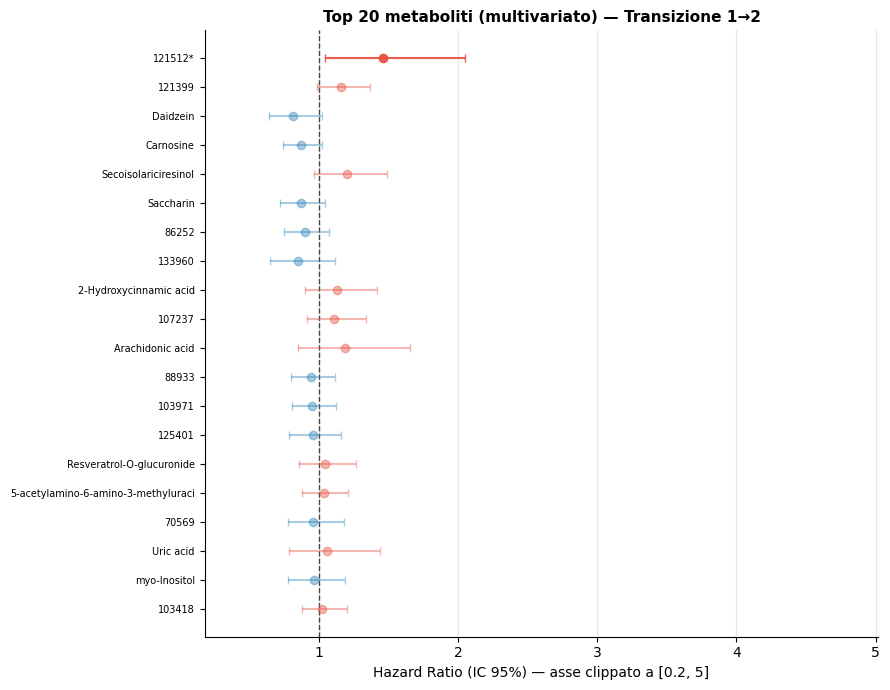

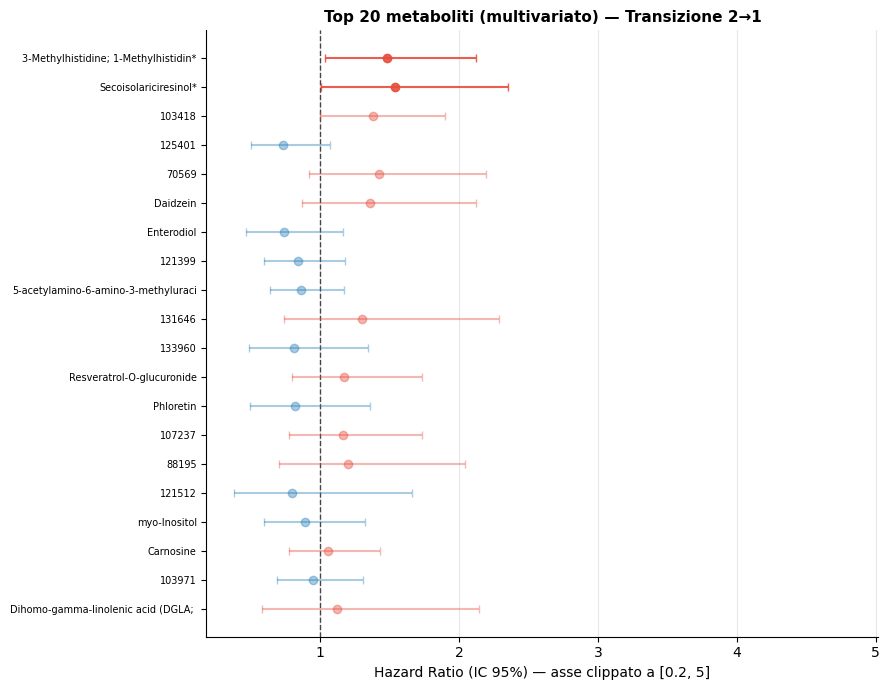

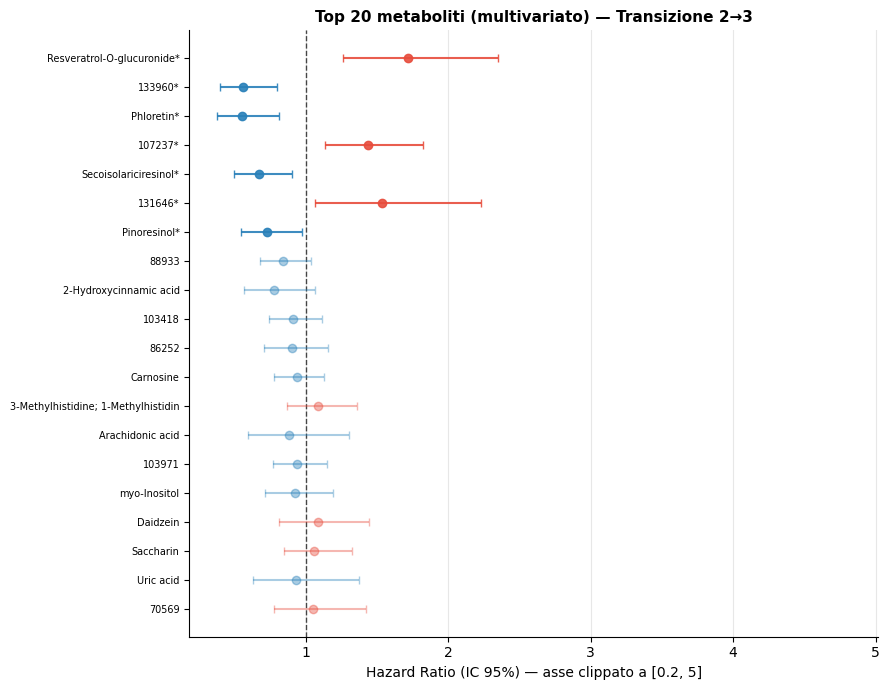

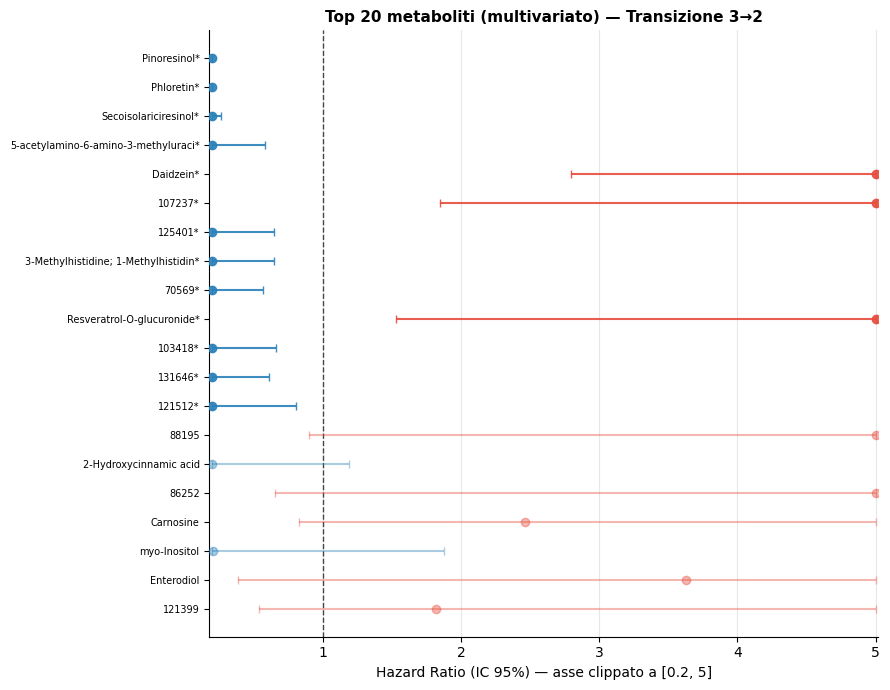

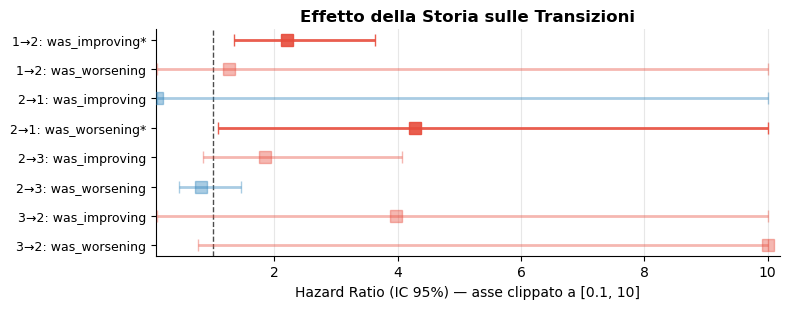

In [20]:
# ── Forest plot metaboliti dal modello multivariato ───────────────────
met_results = df_hr_multi[df_hr_multi['Tipo'] == 'Metabolita'].copy()

HR_CLIP = 5.0   # clip HR axis per leggibilità

for trans in TRANS_LABELS:
    sub = met_results[met_results['Transizione'] == trans].copy()
    sub = sub.dropna(subset=['HR','HR_lo','HR_hi'])
    sub = sub.nsmallest(20, 'p_value')
    if len(sub) == 0:
        continue
    
    fig, ax = plt.subplots(figsize=(9, max(4, len(sub)*0.35)))
    for row_idx, (_, row) in enumerate(sub.iterrows()):
        y = len(sub) - row_idx
        color = '#e74c3c' if row['HR'] > 1 else '#2980b9'
        alpha = 0.9 if row['p_value'] < 0.05 else 0.4
        hr_c  = np.clip(row['HR'], 1/HR_CLIP, HR_CLIP)
        lo_c  = np.clip(row['HR_lo'], 1/HR_CLIP, HR_CLIP)
        hi_c  = np.clip(row['HR_hi'], 1/HR_CLIP, HR_CLIP)
        ax.errorbar(hr_c, y, xerr=[[hr_c - lo_c],[hi_c - hr_c]],
                    fmt='o', color=color, markersize=6, capsize=3, linewidth=1.5,
                    alpha=alpha, zorder=3)
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlim(1/HR_CLIP - 0.02, HR_CLIP + 0.02)
    ylabels = [f"{r['Covariata'][:35]}{'*' if r['p_value']<0.05 else ''}"
               for _, r in sub.iterrows()]
    ax.set_yticks(range(1, len(sub)+1))
    ax.set_yticklabels(ylabels[::-1], fontsize=7)
    ax.set_xlabel('Hazard Ratio (IC 95%) — asse clippato a [0.2, 5]', fontsize=10)
    ax.set_title(f'Top 20 metaboliti (multivariato) — Transizione {trans}',
                 fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

# ── Forest plot storia ────────────────────────────────────────────────
hist_df = df_hr_multi[df_hr_multi['Tipo'] == 'Storia'].copy()
if len(hist_df) > 0:
    HR_CLIP_H = 10.0
    fig, ax = plt.subplots(figsize=(8, max(3, len(hist_df)*0.4)))
    for row_idx, (_, row) in enumerate(hist_df.iterrows()):
        y = len(hist_df) - row_idx
        color = '#e74c3c' if row['HR'] > 1 else '#2980b9'
        alpha = 0.9 if row['p_value'] < 0.05 else 0.4
        hr_c  = np.clip(row['HR'], 1/HR_CLIP_H, HR_CLIP_H)
        lo_c  = np.clip(row['HR_lo'], 1/HR_CLIP_H, HR_CLIP_H)
        hi_c  = np.clip(row['HR_hi'], 1/HR_CLIP_H, HR_CLIP_H)
        ax.errorbar(hr_c, y, xerr=[[hr_c - lo_c],[hi_c - hr_c]],
                    fmt='s', color=color, markersize=8, capsize=4, linewidth=2,
                    alpha=alpha, zorder=3)
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlim(1/HR_CLIP_H - 0.02, HR_CLIP_H + 0.2)
    ylabels_h = [f"{r['Transizione']}: {r['Covariata']}{'*' if r['p_value']<0.05 else ''}"
                 for _, r in hist_df.iterrows()]
    ax.set_yticks(range(1, len(hist_df)+1))
    ax.set_yticklabels(ylabels_h[::-1], fontsize=9)
    ax.set_xlabel('Hazard Ratio (IC 95%) — asse clippato a [0.1, 10]')
    ax.set_title('Effetto della Storia sulle Transizioni', fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

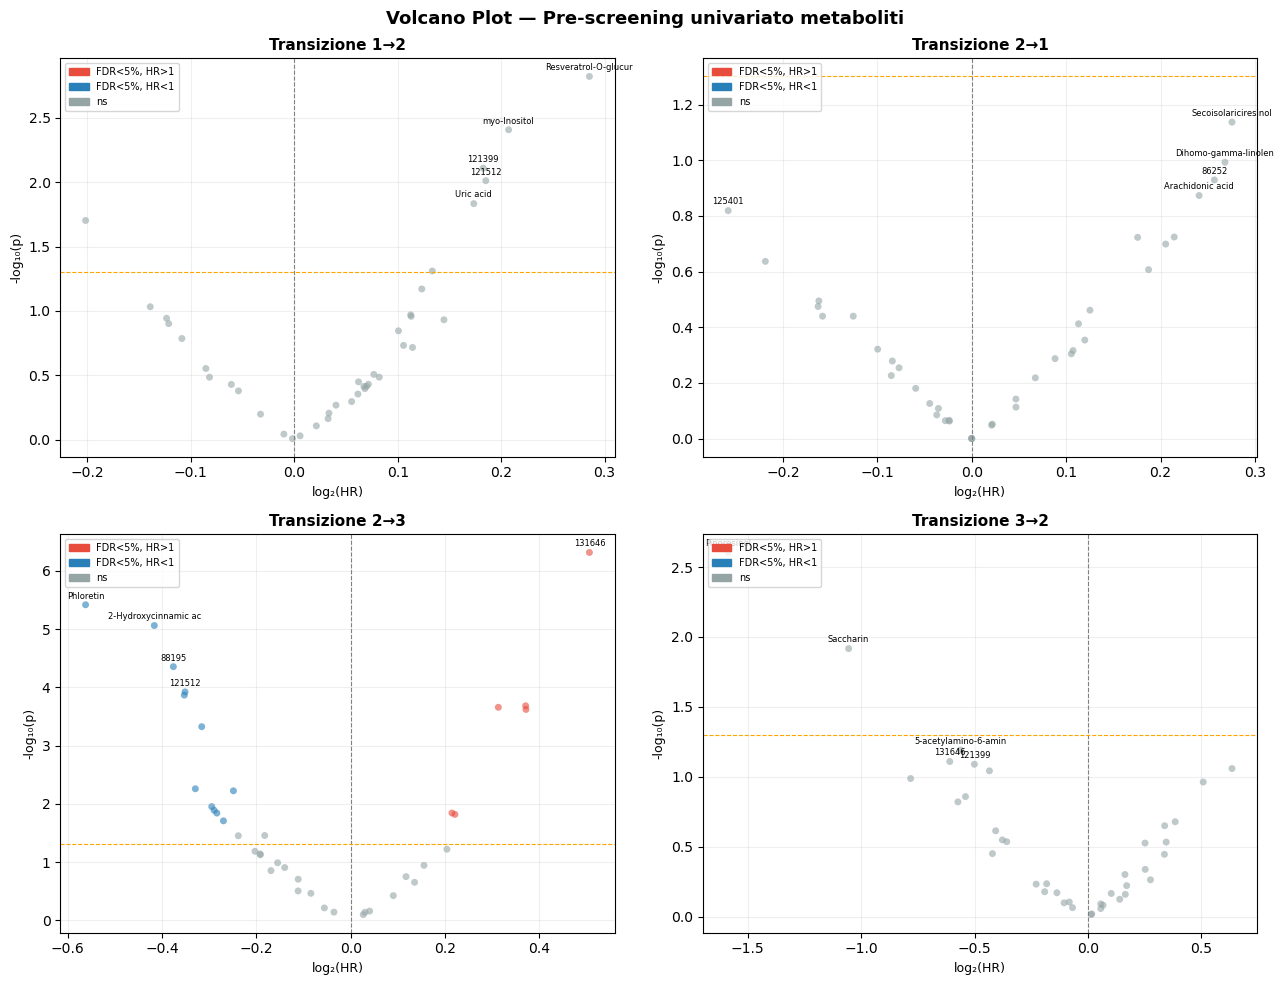

In [21]:
# ── Volcano plot (pre-screening univariato) ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes_flat = axes.flatten()

for ax, trans in zip(axes_flat, TRANS_LABELS):
    sub = df_hr_univ[df_hr_univ['Transizione'] == trans].dropna(subset=['p_value','HR'])
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    
    log2hr = np.log2(sub['HR'].clip(0.01, 100))
    neg_log_p = -np.log10(sub['p_value'].clip(1e-10, 1))
    
    colors = ['#e74c3c' if (q < 0.05 and hr > 1)
              else '#2980b9' if (q < 0.05 and hr < 1)
              else '#95a5a6'
              for q, hr in zip(sub['q_value'], sub['HR'])]
    
    ax.scatter(log2hr, neg_log_p, c=colors, alpha=0.6, s=25, edgecolors='none')
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(-np.log10(0.05), color='orange', linestyle='--', linewidth=0.8, label='p=0.05')
    
    top5 = sub.nsmallest(5, 'p_value')
    for _, r in top5.iterrows():
        ax.annotate(r['Metabolita'][:20],
                   (np.log2(max(r['HR'], 0.01)), -np.log10(max(r['p_value'], 1e-10))),
                   fontsize=6, ha='center', va='bottom',
                   xytext=(0, 3), textcoords='offset points')
    
    ax.set_xlabel('log₂(HR)', fontsize=9)
    ax.set_ylabel('-log₁₀(p)', fontsize=9)
    ax.set_title(f'Transizione {trans}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)
    patches_v = [
        mpatches.Patch(color='#e74c3c', label='FDR<5%, HR>1'),
        mpatches.Patch(color='#2980b9', label='FDR<5%, HR<1'),
        mpatches.Patch(color='#95a5a6', label='ns')
    ]
    ax.legend(handles=patches_v, fontsize=7, loc='upper left')

plt.suptitle('Volcano Plot — Pre-screening univariato metaboliti', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

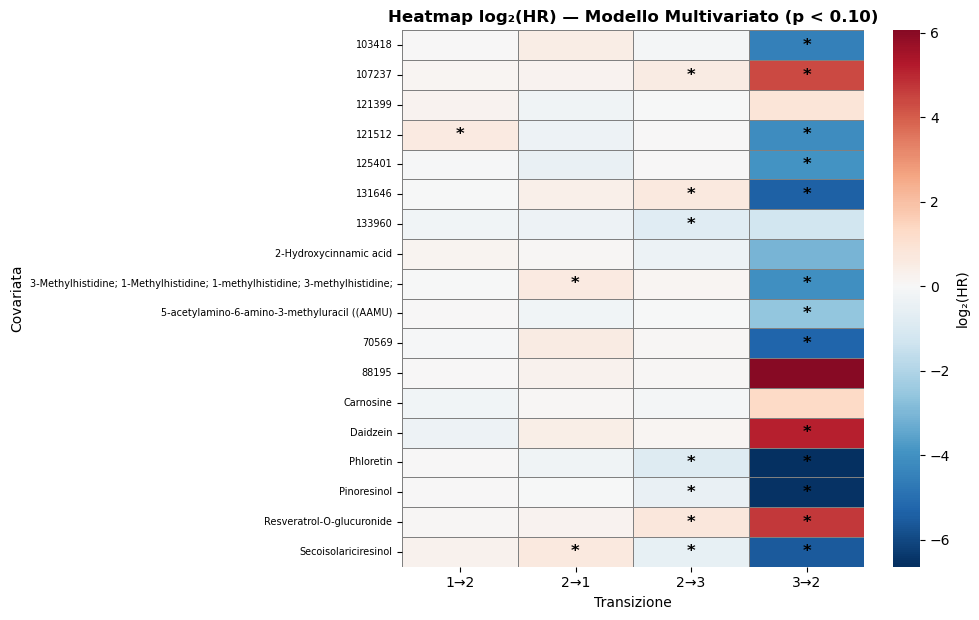

In [22]:
# ── Heatmap HR modello multivariato ───────────────────────────────────
met_sig = df_hr_multi[(df_hr_multi['Tipo']=='Metabolita') &
                       (df_hr_multi['p_value'] < 0.10)]['Covariata'].unique()

if len(met_sig) > 0:
    pivot_data = df_hr_multi[df_hr_multi['Covariata'].isin(met_sig) & 
                              (df_hr_multi['Tipo']=='Metabolita')]
    pivot = pivot_data.pivot_table(index='Covariata', columns='Transizione', values='HR')
    pivot_p = pivot_data.pivot_table(index='Covariata', columns='Transizione', values='p_value')
    
    if len(pivot) > 30:
        top30 = (pivot_data.groupby('Covariata')['p_value'].min()
                 .nsmallest(30).index)
        pivot = pivot.loc[pivot.index.isin(top30)]
        pivot_p = pivot_p.loc[pivot_p.index.isin(top30)]
    
    log2_pivot = np.log2(pivot.clip(0.01, 100))
    
    fig_h = max(6, len(pivot) * 0.35)
    fig, ax = plt.subplots(figsize=(10, fig_h))
    sns.heatmap(log2_pivot, cmap='RdBu_r', center=0, ax=ax,
                xticklabels=True, yticklabels=True,
                linewidths=0.5, linecolor='gray',
                cbar_kws={'label': 'log₂(HR)'})
    
    for i, met in enumerate(pivot.index):
        for j, tr in enumerate(pivot.columns):
            p = pivot_p.loc[met, tr] if (met in pivot_p.index and tr in pivot_p.columns) else np.nan
            if not np.isnan(p) and p < 0.05:
                ax.text(j + 0.5, i + 0.5, '*', ha='center', va='center',
                        color='black', fontsize=12, fontweight='bold')
    
    ax.set_title('Heatmap log₂(HR) — Modello Multivariato (p < 0.10)',
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout()
    plt.show()
else:
    print('Nessun metabolita con p < 0.10 nel modello multivariato.')

---
## Riepilogo

### Metodi applicati
- **Modello**: Continuous-Time Multi-State Markov Model (CTMC-MSM)
- **3 stati**: Fit (FI < 0.10), Pre-fragile (0.10 ≤ FI < 0.25), Fragile (FI ≥ 0.25)
- **4 transizioni** bidirezionali adiacenti (1↔2, 2↔3)
- **Auto-transizioni** esplicitamente modellate e visualizzate (diagonale di P(Δt))
- **Covariate**: solo metaboliti plasmatici (quintili time-varying, pooled su tutti i timepoint)
- **Storia**: stato precedente incluso come covariata (was_improving / was_worsening)
- **Pre-screening univariato** → selezione metaboliti con p < 0.10
- **Modello multivariato finale** con metaboliti selezionati + storia
- **SE e IC**: da Hessiano numerico
- **Correzione multipla**: FDR di Benjamini-Hochberg (pre-screening)

### Interpretazione
- Un **HR > 1** indica che un aumento della covariata accelera quella transizione
- I **sojourn time** indicano il tempo medio nello stesso stato
- Le **auto-transizioni** $P_{ii}(\Delta t)$ quantificano la stabilità di ogni stato
- La **storia** cattura l'inerzia del processo: se un precedente miglioramento/peggioramento modifica le transizioni future

### Riferimenti
- Jackson CH (2011). Multi-state models for panel data: the msm package for R. *JSS* 38(8)
- Mendonça N et al. (2020). Protein intake and transitions between frailty states. *Age & Ageing* 49(2)